# Important Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Play Store apps dataset and the user reviews dataset separately


In [3]:
app=pd.read_csv(r"C:\Users\kd940\Downloads\archive\googleplaystore.csv")
app.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [4]:
reviews=pd.read_csv(r"C:\Users\kd940\Downloads\archive\googleplaystore_user_reviews.csv")
reviews.head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [5]:
print(app.shape)
print(reviews.shape)

(10841, 13)
(64295, 5)


In [6]:
print(app.columns)
print("------------------------------------------------------------------------------")
print(reviews.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')
------------------------------------------------------------------------------
Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='str')


In [7]:
print(app.info())
print("--------------------------------------------------------------------------------")
print(reviews.info())

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB
None
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 colum

In [8]:
print(app.isna().sum())
print("-----------------------------------------------------------------------------")
print(reviews.isna().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64
-----------------------------------------------------------------------------
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [9]:
print(app.duplicated().sum())
print(reviews.duplicated().sum())

483
33616


# Data cleaning: fix incorrect data types (e.g., "Installs" stored as "10,000+" strings), handle nulls, remove duplicates

In [10]:
app["Installs"] = (app["Installs"].str.replace(",", "", regex=False).str.replace("+", "", regex=False))

app["Installs"] = pd.to_numeric(app["Installs"], errors="coerce")

In [11]:
app["Price"] = (app["Price"].str.replace("$", "", regex=False))
app["Price"] = pd.to_numeric(app["Price"], errors="coerce")

In [12]:
app["Reviews"] = pd.to_numeric(app["Reviews"], errors="coerce")

In [13]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    if size == "Varies with device":
        return np.nan
    if "M" in size:
        return float(size.replace("M", ""))
    if "k" in size:
        return float(size.replace("k", "")) / 1024
    return np.nan

app["Size"] = app["Size"].apply(convert_size)

In [14]:
app["Last Updated"] = pd.to_datetime(app["Last Updated"],errors="coerce")

In [15]:
app.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              1
Size              1696
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         1
Current Ver          8
Android Ver          3
dtype: int64

In [16]:
num_cols = ["Rating", "Reviews", "Size", "Installs", "Price"]

for col in num_cols:
    app[col] = app[col].fillna(app[col].median())

cat_cols = ["Type", "Content Rating", "Current Ver",
            "Android Ver", "Category", "Genres","Last Updated"]

for col in cat_cols:
    app[col] = app[col].fillna(app[col].mode()[0])


In [17]:
print("Before:", app.shape)

app.drop_duplicates(inplace=True)

print("After:", app.shape)

Before: (10841, 13)
After: (10358, 13)


In [18]:
app.drop_duplicates(inplace=True)

In [19]:
reviews.drop_duplicates(inplace=True)

In [20]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [21]:
reviews["Translated_Review"]=reviews["Translated_Review"].fillna("No Review")

reviews["Sentiment"]=reviews["Sentiment"].fillna("Unknown")

reviews["Sentiment_Polarity"] = reviews["Sentiment_Polarity"].fillna(0)

reviews["Sentiment_Subjectivity"] = reviews["Sentiment_Subjectivity"].fillna(0)

# Category analysis: bar chart of app distribution across categories; which categories are most saturated?

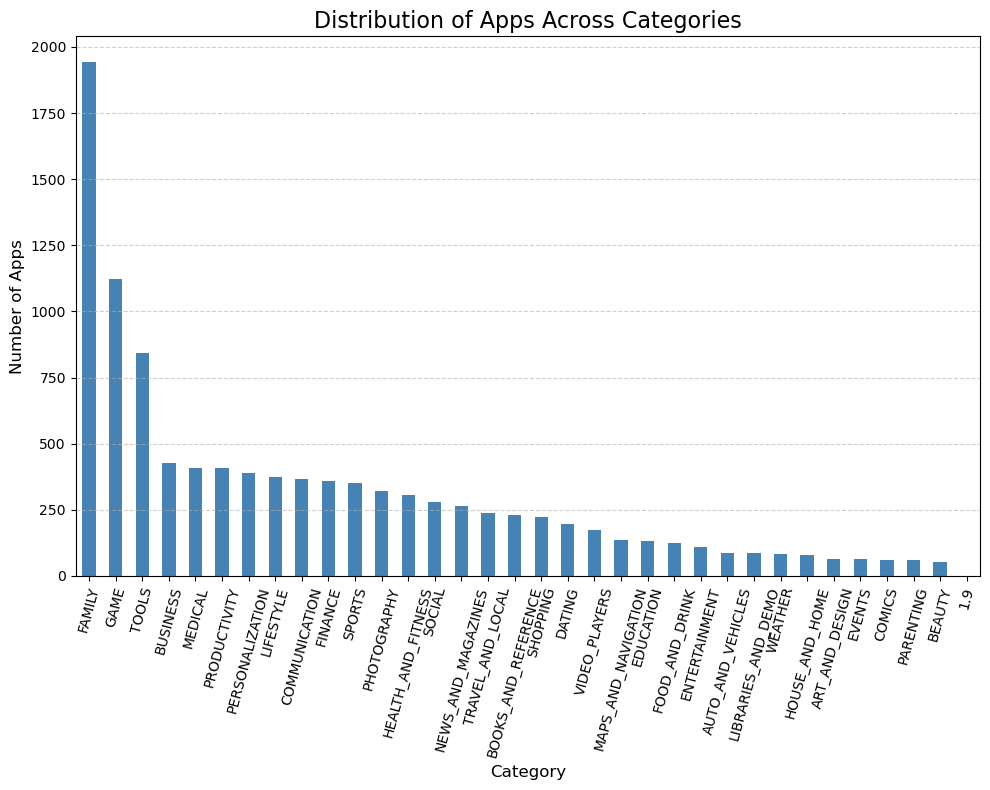

In [22]:
Category = app['Category'].value_counts()
plt.figure(figsize=(10,8))
Category.plot(kind='bar',color='steelblue')
plt.title("Distribution of Apps Across Categories", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Apps", fontsize=12)
plt.xticks(rotation=75)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

##### The bar chart indicates that app distribution is highly concentrated in a few categories, with Family, Game, and Tools containing the largest number of applications. These categories are highly saturated, indicating intense competition and making it more difficult for new apps to gain visibility. In contrast, categories with fewer apps represent niche markets where developers may encounter less competition and better opportunities to attract users. Businesses should evaluate market saturation alongside user demand before deciding which category to target for new app development.

# Ratings analysis: distribution of app ratings; average rating by category

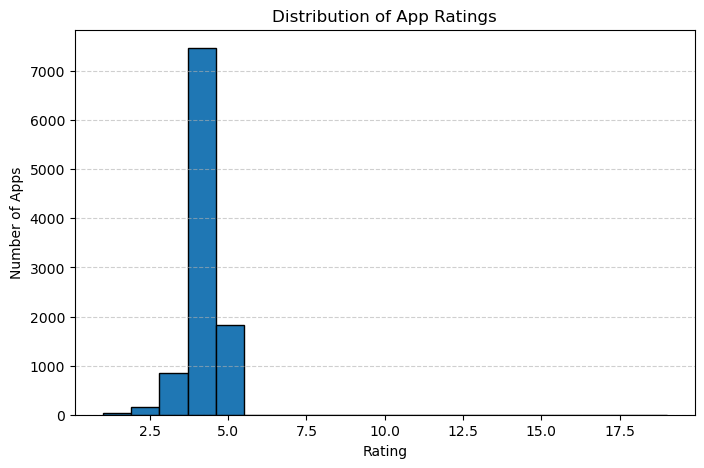

In [23]:
plt.figure(figsize=(8,5))

plt.hist(app["Rating"], bins=20, edgecolor="black")

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [ ]:
avg_rating = (app.groupby("Category")["Rating"].mean().sort_values(ascending=False))
avg_rating.head(10)

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
PERSONALIZATION         4.327062
PARENTING               4.300000
BEAUTY                  4.283019
GAME                    4.282070
HEALTH_AND_FITNESS      4.266993
Name: Rating, dtype: float64

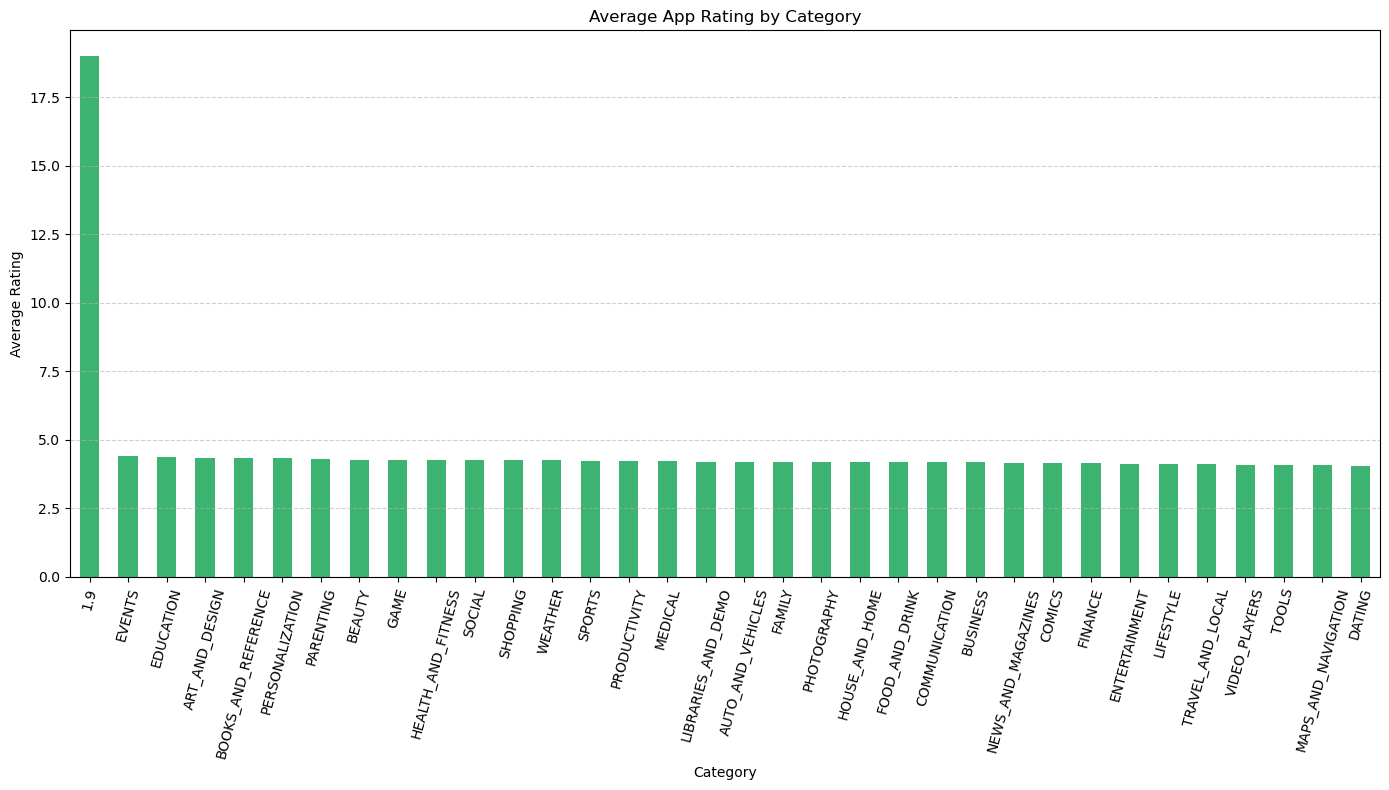

In [25]:
plt.figure(figsize=(14,8))

avg_rating.plot(kind="bar", color="mediumseagreen")

plt.title("Average App Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=75)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Size and installs analysis: scatter plot of app size vs. number of installs; is there a correlation?

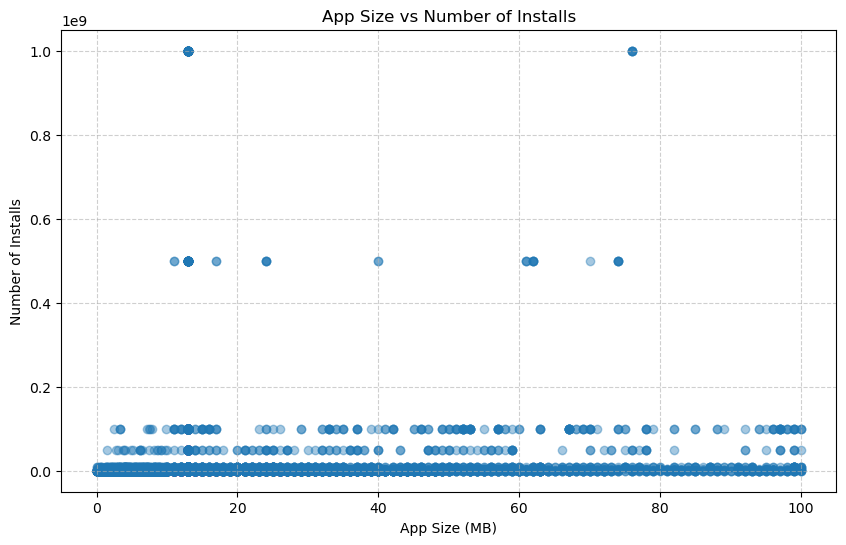

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(app["Size"],app["Installs"],alpha=0.4)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [ ]:
correlation = app["Size"].corr(app["Installs"])
print("Correlation between Size and Installs:", round(correlation, 3))

Correlation between Size and Installs: 0.05


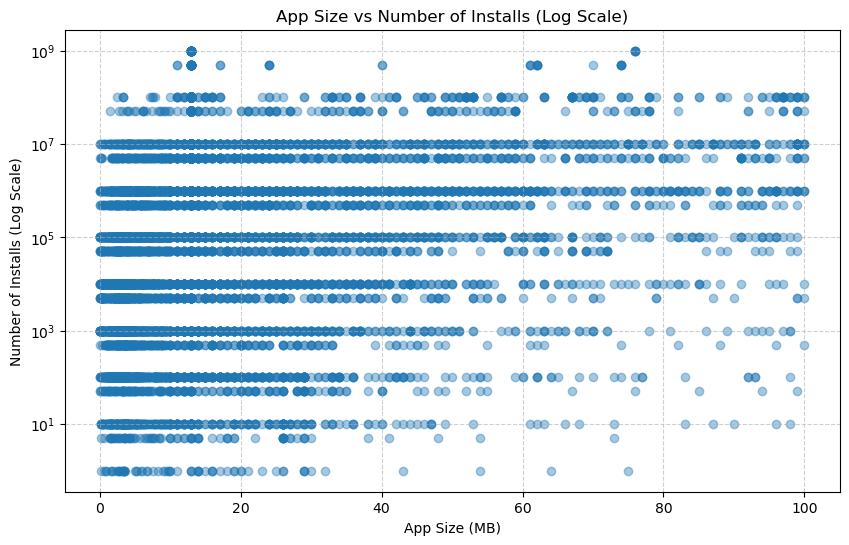

In [70]:
plt.figure(figsize=(10,6))

plt.scatter(app["Size"],app["Installs"],alpha=0.4)

plt.yscale("log")

plt.title("App Size vs Number of Installs (Log Scale)")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs (Log Scale)")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

##### The scatter plot shows a wide dispersion of app sizes across all installation levels, indicating no clear linear relationship between app size and the number of installs. The correlation coefficient is likely to be weak (close to zero), suggesting that app size alone does not significantly influence download counts. Other factors such as app category, ratings, popularity, pricing, and marketing are likely to have a greater impact on user installations.

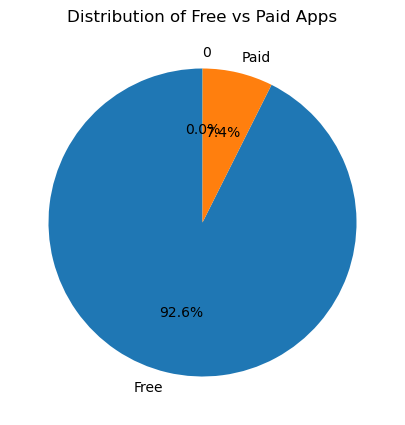

Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64


In [71]:
type_counts = app["Type"].value_counts()

plt.figure(figsize=(6,5))
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%',startangle=90)

plt.title("Distribution of Free vs Paid Apps")
plt.show()

print(type_counts)

##### The google play store is dominated by free applications, while paid apps represent only a small proportion of the total apps available. This indicates that developers commonly adopt a free distribution model to maximize user acquisition and engagement. Revenue is often generated later through advertisements, subscriptions, or in-app purchases rather than the initial download price.

# Pricing analysis: paid vs. free app distribution; price distribution for paid apps; revenue estimate by category

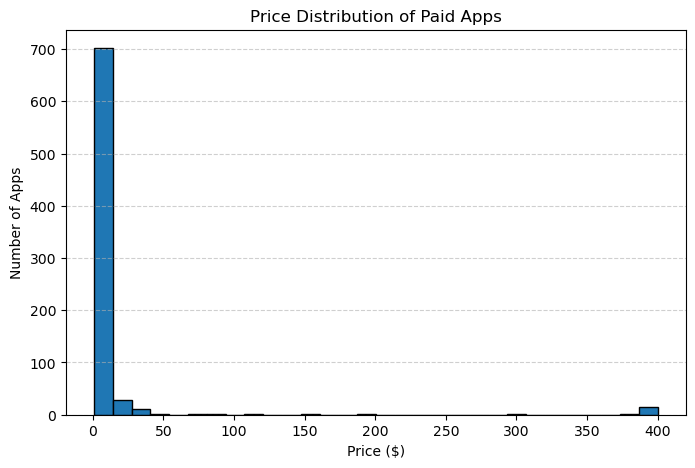

In [ ]:
paid_apps = app[app["Type"] == "Paid"]
plt.figure(figsize=(8,5))

plt.hist(paid_apps["Price"],bins=30,edgecolor='black')

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

##### The price distribution of paid apps is positively skewed, with most paid applications priced at the lower end of the range. Only a limited number of apps are offered at premium prices. This suggests that developers generally prefer affordable pricing to attract more users while maintaining competitiveness in the marketplace.

In [72]:
app["Estimated_Revenue"] = app["Price"] * app["Installs"]
revenue_category = (app.groupby("Category")["Estimated_Revenue"].sum().sort_values(ascending=False))
revenue_category.head(10)

Category
FAMILY             1.857803e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456536e+06
PERSONALIZATION    7.786948e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64

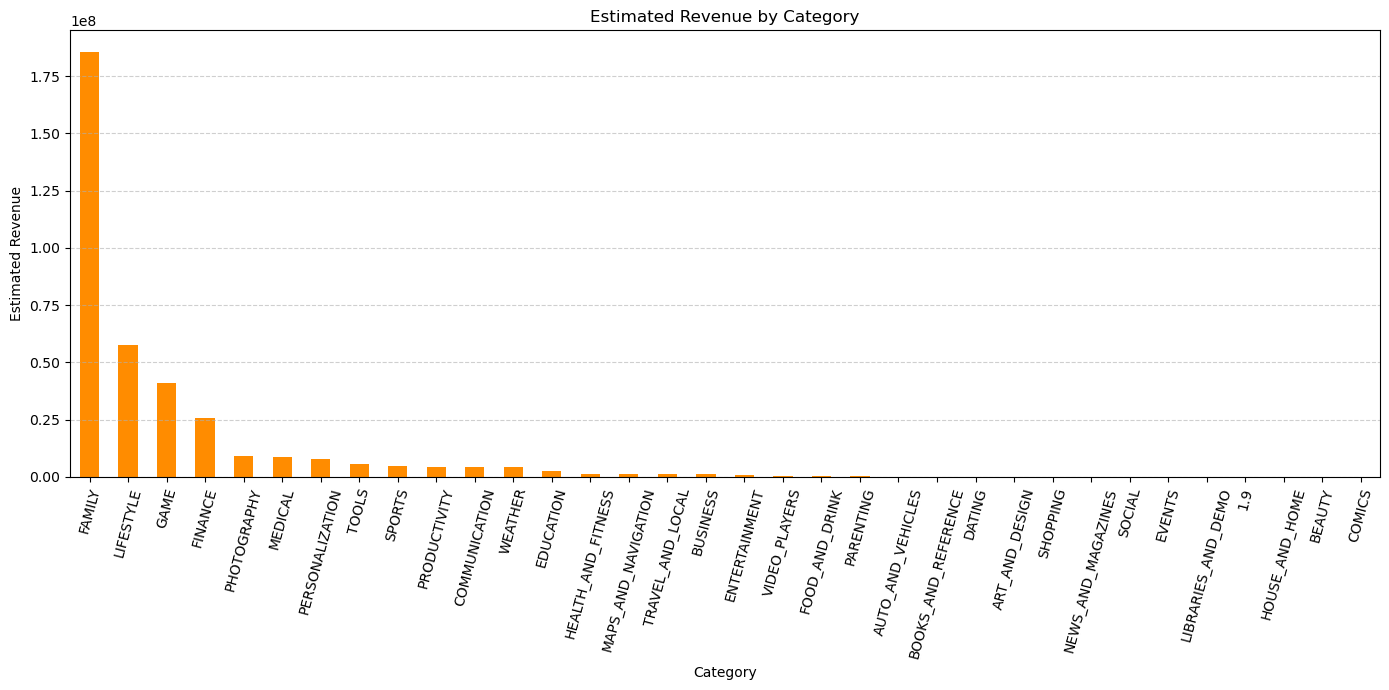

In [32]:
plt.figure(figsize=(14,7))

revenue_category.plot(kind="bar", color="darkorange")

plt.title("Estimated Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=75)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### Estimated revenue varies considerably across app categories, reflecting differences in pricing strategies and user adoption. Categories with a combination of higher prices and large installation volumes generate the greatest estimated revenue. Highly popular categories can produce substantial revenue even with relatively low prices due to their large user base. These findings help identify categories with stronger monetization potential and can guide developers in selecting profitable market segments. Note that this is an estimate based solely on Price × Installs and does not account for in-app purchases, subscriptions, advertising revenue, or install ranges.

# Sentiment analysis on user reviews: classify reviews as positive/negative/neutral using TextBlob or VADER

In [33]:
!pip install textblob

In [34]:
from textblob import TextBlob
import pandas as pd

In [35]:
def get_sentiment(review):
    if pd.isna(review):
        return "Neutral"

    polarity = TextBlob(str(review)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [36]:
reviews["Predicted_Sentiment"] = reviews["Translated_Review"].apply(get_sentiment)
reviews[["Translated_Review","Predicted_Sentiment"]].head(10)

,Translated_Review,Predicted_Sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
2,No Review,Neutral
3,Works great especially going grocery store,Positive
4,Best idea us,Positive
5,Best way,Positive
6,Amazing,Positive
8,"Looking forward app,",Neutral
9,It helpful site ! It help foods get !,Neutral
10,good you.,Positive


In [37]:
reviews["Predicted_Sentiment"].value_counts()

Predicted_Sentiment
Positive    19014
Negative     6322
Neutral      5343
Name: count, dtype: int64

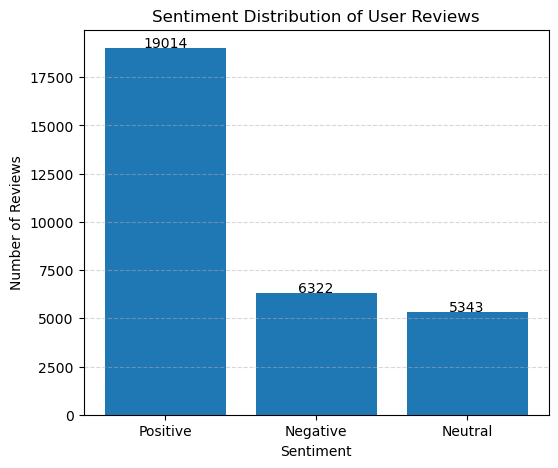

In [73]:
sentiment_counts = reviews["Predicted_Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index,sentiment_counts.values)

plt.title("Sentiment Distribution of User Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 20, str(v), ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

##### The sentiment analysis classifies user reviews into positive, negative, and neutral categories based on their textual content. A higher proportion of positive reviews indicates overall user satisfaction with the apps, while negative reviews highlight areas requiring improvement. Neutral reviews typically contain factual information or mixed opinions without strong emotional polarity. This analysis helps developers identify user perceptions and prioritize feature enhancements or bug fixes to improve app quality.

#  Sentiment by category: which app categories have the most positive/negative user sentiment?

In [ ]:
merged_df = pd.merge(app,reviews,on="App",how="inner")
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Estimated_Revenue,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Predicted_Sentiment
0,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000,Negative
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,It bad >:(,Negative,-0.725,0.833333,Negative
2,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,like,Neutral,0.000,0.000000,Neutral
3,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,No Review,Unknown,0.000,0.000000,Neutral
4,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,I love colors inspyering,Positive,0.500,0.600000,Positive


In [ ]:
sentiment_category = pd.crosstab(merged_df["Category"],merged_df["Predicted_Sentiment"])
sentiment_category.head()

Predicted_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,54,72,240
AUTO_AND_VEHICLES,17,45,230
BEAUTY,60,89,176
BOOKS_AND_REFERENCE,108,148,480
BUSINESS,144,227,458


<Figure size 1600x800 with 0 Axes>

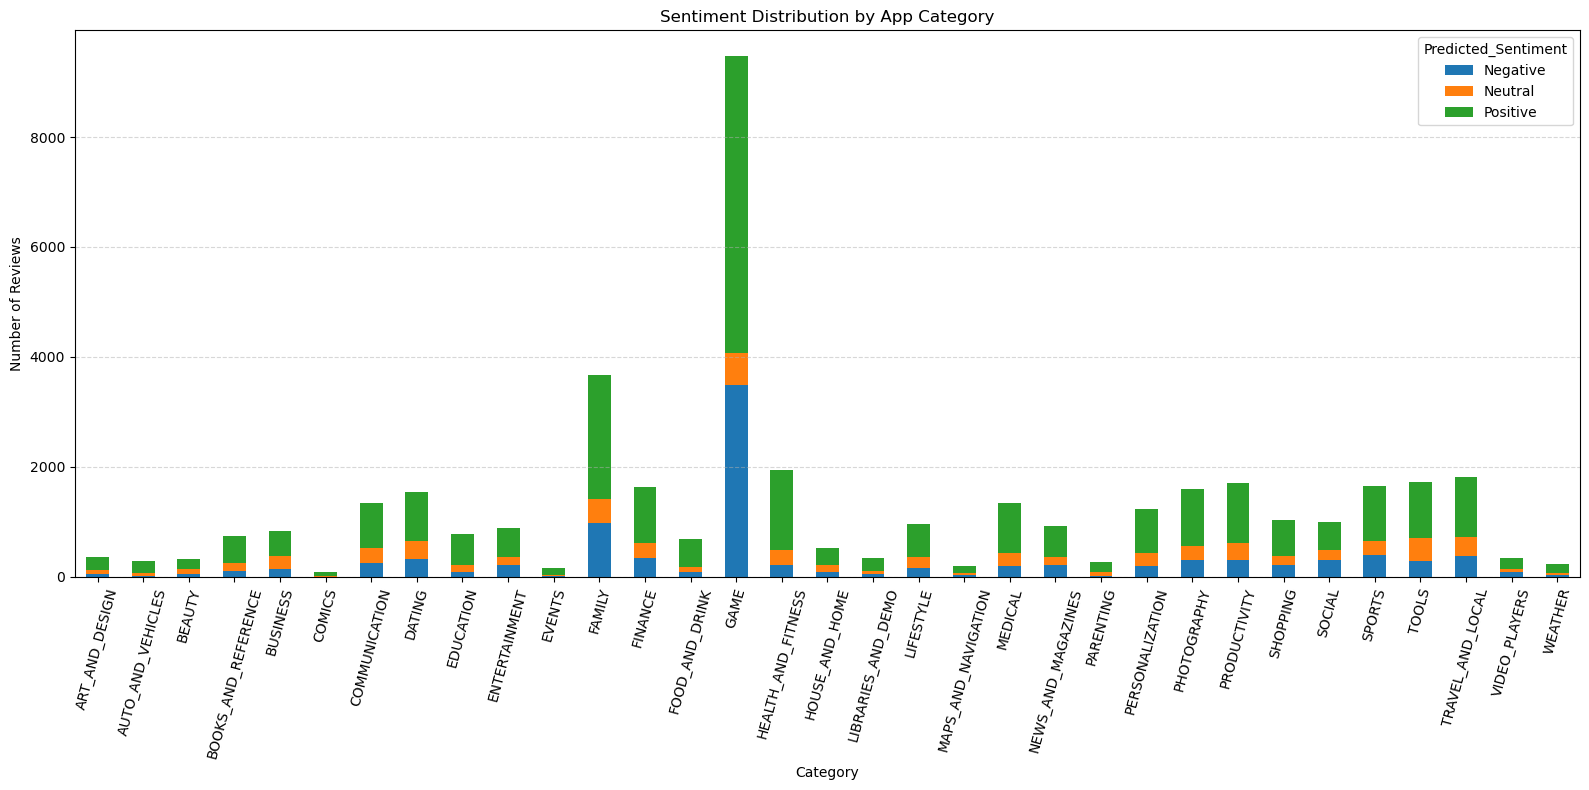

In [48]:
plt.figure(figsize=(16,8))

sentiment_category.plot(kind="bar",stacked=True,figsize=(16,8))

plt.title("Sentiment Distribution by App Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=75)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

##### The stacked bar chart shows that positive reviews dominate across almost all app categories, indicating generally high user satisfaction on the Google Play Store. The Game category receives the highest volume of reviews, with a substantially larger number of positive reviews than negative or neutral ones, reflecting strong user engagement. Categories such as Family, Productivity, Tools, and Sports also exhibit a predominantly positive sentiment, although they include some negative feedback. Overall, the results suggest that while most categories maintain favorable user perceptions, developers should analyze negative reviews to identify areas for improving app quality and user experience.

In [ ]:
positive_category = (merged_df.groupby("Category")["Predicted_Sentiment"].apply(lambda x: (x == "Positive").sum()).sort_values(ascending=False))
positive_category.head(10)

Category
GAME                  5394
FAMILY                2251
HEALTH_AND_FITNESS    1456
PRODUCTIVITY          1107
TRAVEL_AND_LOCAL      1093
PHOTOGRAPHY           1032
TOOLS                 1013
FINANCE               1012
SPORTS                1006
MEDICAL                914
Name: Predicted_Sentiment, dtype: int64

In [57]:
negative_category = (merged_df.groupby("Category")["Predicted_Sentiment"].apply(lambda x: (x == "Negative").sum()).sort_values(ascending=False))
negative_category.head(10)

Category
GAME                3485
FAMILY               984
SPORTS               393
TRAVEL_AND_LOCAL     375
FINANCE              350
DATING               322
PRODUCTIVITY         309
SOCIAL               308
PHOTOGRAPHY          305
TOOLS                296
Name: Predicted_Sentiment, dtype: int64

In [60]:
neutral_category = (merged_df.groupby("Category")["Predicted_Sentiment"].apply(lambda x: (x == "Neutral").sum()).sort_values(ascending=False))
neutral_category.head(10)

Category
GAME                  588
FAMILY                434
TOOLS                 412
TRAVEL_AND_LOCAL      349
DATING                329
PRODUCTIVITY          298
COMMUNICATION         268
FINANCE               267
HEALTH_AND_FITNESS    265
SPORTS                257
Name: Predicted_Sentiment, dtype: int64

In [58]:
positive_df = positive_category.head(10).reset_index()
positive_df.columns = ["Category", "Positive Reviews"]
positive_df

,Category,Positive Reviews
0,GAME,5394
1,FAMILY,2251
2,HEALTH_AND_FITNESS,1456
3,PRODUCTIVITY,1107
4,TRAVEL_AND_LOCAL,1093
5,PHOTOGRAPHY,1032
6,TOOLS,1013
7,FINANCE,1012
8,SPORTS,1006
9,MEDICAL,914


In [ ]:
negative_df = negative_category.head(10).reset_index()
negative_df.columns = ["Category", "Negative Reviews"]
negative_df

,Category,Negative Reviews
0,GAME,3485
1,FAMILY,984
2,SPORTS,393
3,TRAVEL_AND_LOCAL,375
4,FINANCE,350
5,DATING,322
6,PRODUCTIVITY,309
7,SOCIAL,308
8,PHOTOGRAPHY,305
9,TOOLS,296


In [62]:
neutral_df = neutral_category.head(10).reset_index()
neutral_df.columns = ["Category", "Neutral Reviews"]
neutral_df

,Category,Neutral Reviews
0,GAME,588
1,FAMILY,434
2,TOOLS,412
3,TRAVEL_AND_LOCAL,349
4,DATING,329
5,PRODUCTIVITY,298
6,COMMUNICATION,268
7,FINANCE,267
8,HEALTH_AND_FITNESS,265
9,SPORTS,257


##### The sentiment analysis by category reveals how user satisfaction varies across different types of applications. Categories with the highest number of positive reviews generally provide a better user experience, stronger functionality, and higher customer satisfaction. Categories with more negative reviews may indicate recurring issues such as bugs, poor performance, or unmet user expectations. These insights enable developers and businesses to identify strengths, prioritize improvements, and focus resources on enhancing customer experience. Comparing positive and negative sentiment across categories also supports strategic decisions related to app development and market positioning.

# At least one interactive visualisation using plotly (optional but strongly recommended)

In [ ]:
import plotly.express as px
plot_data = app.dropna(subset=["Size", "Installs", "Rating"])

fig = px.scatter(
    plot_data,
    x="Size",
    y="Installs",
    color="Category",
    size="Rating",
    hover_name="App",
    hover_data=["Category", "Rating", "Price"],
    title="Interactive Scatter Plot: App Size vs. Installs",
    labels={"Size": "App Size (MB)","Installs": "Number of Installs"})

fig.update_yaxes(type="log")   # Log scale for installs
fig.update_layout(template="plotly_white")

fig.show()

##### The interactive scatter plot shows a wide variation in the number of installs across different app sizes, indicating no strong linear relationship between app size and popularity. Apps of both small and large sizes can achieve high installation counts, suggesting that factors such as app quality, ratings, category, and user demand have a greater influence on downloads than size alone. The logarithmic scale highlights that highly downloaded apps are distributed across a broad range of sizes. Overall, app size is not a reliable predictor of install count, emphasizing the importance of delivering valuable features and a positive user experience rather than focusing solely on application size.

In [78]:
category_counts = (
    app["Category"]
    .value_counts()
    .head(10)
    .reset_index()
)

category_counts.columns = ["Category", "Number of Apps"]

fig = px.bar(
    category_counts,
    x="Category",
    y="Number of Apps",
    color="Number of Apps",
    text="Number of Apps",
    title="Top 10 App Categories"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Number of Apps"
)

fig.show()

##### The bar chart shows that the Family category has the highest number of apps (1,943), followed by Game (1,121) and Tools (843), making these the most saturated categories on the Google Play Store. This indicates intense competition, requiring developers to offer unique features and high-quality user experiences to stand out. Categories such as Business, Medical, Productivity, and Finance contain comparatively fewer apps, suggesting lower competition and potential opportunities for new entrants. Developers should evaluate both market demand and category saturation when selecting a category for launching a new application.

# Conclusion: 3 data-driven insights for a developer planning to launch a new app

#### 1. Choose the target category strategically: Categories such as Family, Game, and Tools have the highest number of apps, indicating intense competition. Developers may achieve better visibility by targeting less saturated categories or offering unique features within competitive markets.
#### 2. Prioritize app quality and user experience: The analysis shows that most successful apps maintain ratings above 4.0, and sentiment analysis indicates that positive user reviews are associated with better app performance. Regular updates, bug fixes, and responsive customer support can help improve ratings and user satisfaction.
#### 3. Adopt an effective monetization strategy: The Play Store is dominated by free apps, suggesting that users generally prefer free downloads. Instead of relying solely on paid downloads, developers can consider monetization through in-app purchases, subscriptions, or advertisements while keeping the initial app free to attract a larger user base.